# When Compact Encoders Should Abstain  
## Selective Prediction and Calibration under Distribution Shift in NLI

This notebook implements a full experiment pipeline for the project:

**When Compact Encoders Should Abstain: Selective Prediction and Calibration under Distribution Shift in NLI**

The pipeline covers:

- SNLI training and in-distribution evaluation
- OOD evaluation on MNLI matched, MNLI mismatched, and HANS
- a compact encoder-only Transformer baseline implemented in pure PyTorch
- a strong BERT baseline with symmetric preprocessing
- post-hoc temperature scaling
- confidence-based abstention and risk-coverage analysis
- slice analysis for negation, lexical overlap, length buckets, and HANS heuristics
- throughput, latency, and parameter-count reporting
- export of tables, figures, raw predictions, and summary JSON files

The notebook is written to be **Kaggle-friendly**, **config-driven**, and **reproducible**.

## Research protocol

### Main question
Under what values of **coverage**, **risk**, and **calibration** does a compact encoder remain practically useful relative to BERT on in-distribution and shifted NLI data?

### Core hypotheses
1. The compact encoder loses more quality than BERT at full coverage, but the gap narrows when the model is allowed to abstain on low-confidence cases.
2. Distribution shift hurts the compact encoder more severely than BERT, especially on heuristic-heavy or semantically delicate examples.
3. Temperature scaling improves probabilistic quality for both models, but does not remove the OOD reliability gap.
4. There exists a **reliability-constrained coverage threshold** where the compact encoder is still useful.

### Mandatory datasets
- **SNLI**: train / validation / test
- **MNLI matched**: OOD near-shift
- **MNLI mismatched**: OOD genre shift
- **HANS**: diagnostic OOD stress test

### Mandatory metrics
- Classification: accuracy, macro-F1, per-class F1, confusion matrix
- Probabilistic quality: NLL, Brier, ECE, MCE
- Selective prediction: coverage, selective risk, AURC, quality at fixed coverage
- Efficiency: parameter count, throughput, latency, peak memory

### Implementation note
The notebook supports two modes:
- **full research run** for real experiments
- **smoke mode** for fast debugging on small subsets

Set the configuration carefully before launching training. Humanity's favorite hobby is wasting GPU hours because a boolean stayed in the wrong state.

In [1]:

# Kaggle setup
!pip -q install -U datasets transformers accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00


In [2]:

from __future__ import annotations

import gc
import json
import math
import os
import random
import re
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
)
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from transformers.modeling_outputs import SequenceClassifierOutput

pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:

@dataclass
class CompactModelConfig:
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 4
    ff_dim: int = 1024
    dropout: float = 0.1
    max_position_embeddings: int = 256
    layer_norm_eps: float = 1e-5

@dataclass
class TrainConfig:
    epochs: int
    lr: float
    weight_decay: float
    batch_size: int
    eval_batch_size: int
    grad_accum_steps: int = 1
    warmup_ratio: float = 0.06
    max_grad_norm: float = 1.0
    patience: int = 2
    num_workers: int = 2
    amp: bool = True

@dataclass
class ExperimentConfig:
    project_name: str = "eeml_nli_abstention"
    output_root: str = "/kaggle/working/eeml_nli_abstention"
    smoke_mode: bool = False
    smoke_rows_train: int = 12000
    smoke_rows_eval: int = 3000

    tokenizer_candidates: List[str] = field(default_factory=lambda: [
        "google-bert/bert-base-uncased",
        "bert-base-uncased",
    ])
    bert_model_candidates: List[str] = field(default_factory=lambda: [
        "google-bert/bert-base-uncased",
        "bert-base-uncased",
    ])

    max_length: int = 128
    compact_seeds: List[int] = field(default_factory=lambda: [17, 42, 73])
    bert_seeds: List[int] = field(default_factory=lambda: [17, 42, 73])

    compact_cfg: CompactModelConfig = field(default_factory=CompactModelConfig)
    compact_train: TrainConfig = field(default_factory=lambda: TrainConfig(
        epochs=6,
        lr=3e-4,
        weight_decay=0.01,
        batch_size=64,
        eval_batch_size=128,
        grad_accum_steps=1,
        patience=2,
        amp=True,
    ))
    bert_train: TrainConfig = field(default_factory=lambda: TrainConfig(
        epochs=3,
        lr=2e-5,
        weight_decay=0.01,
        batch_size=16,
        eval_batch_size=64,
        grad_accum_steps=2,
        patience=2,
        amp=True,
    ))

    fixed_coverages: List[float] = field(default_factory=lambda: [0.95, 0.90, 0.80, 0.70])
    selective_scores: List[str] = field(default_factory=lambda: ["max_softmax", "margin", "entropy"])
    ece_bins: int = 15
    benchmark_warmup_steps: int = 10
    benchmark_steps: int = 50

CFG = ExperimentConfig()

ROOT = Path(CFG.output_root)
DIRS = {
    "root": ROOT,
    "configs": ROOT / "configs",
    "checkpoints": ROOT / "outputs" / "checkpoints",
    "predictions": ROOT / "outputs" / "predictions",
    "metrics": ROOT / "outputs" / "metrics",
    "figures": ROOT / "outputs" / "figures",
    "tables": ROOT / "outputs" / "tables",
    "logs": ROOT / "outputs" / "logs",
}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

with open(DIRS["configs"] / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)

print("Artifacts will be saved to:", ROOT)

Artifacts will be saved to: /kaggle/working/eeml_nli_abstention


In [4]:

LABEL2ID = {"entailment": 0, "neutral": 1, "contradiction": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
HANS_BINARY_LABEL2ID = {"non-entailment": 0, "entailment": 1}
NEGATION_RE = re.compile(r"\b(no|not|never|none|nobody|nothing|nowhere|neither|nor|cannot|can't|don't|doesn't|isn't|aren't|wasn't|weren't|won't|wouldn't|shouldn't|couldn't|didn't|without)\b", re.IGNORECASE)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def softmax_np(logits: np.ndarray) -> np.ndarray:
    z = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=1, keepdims=True)

def multiclass_brier_score(y_true: np.ndarray, probs: np.ndarray) -> float:
    one_hot = np.eye(probs.shape[1])[y_true]
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def expected_calibration_error(y_true: np.ndarray, probs: np.ndarray, n_bins: int = 15) -> Tuple[float, float, pd.DataFrame]:
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    ece = 0.0
    mce = 0.0
    n = len(y_true)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            rows.append({"bin": i, "bin_left": lo, "bin_right": hi, "count": 0, "avg_conf": np.nan, "avg_acc": np.nan, "gap": np.nan})
            continue
        avg_conf = float(confidences[mask].mean())
        avg_acc = float(accuracies[mask].mean())
        gap = abs(avg_conf - avg_acc)
        ece += (mask.sum() / n) * gap
        mce = max(mce, gap)
        rows.append({"bin": i, "bin_left": lo, "bin_right": hi, "count": int(mask.sum()), "avg_conf": avg_conf, "avg_acc": avg_acc, "gap": gap})

    return float(ece), float(mce), pd.DataFrame(rows)

def compute_multiclass_metrics(y_true: np.ndarray, logits: np.ndarray, split_name: str, prefix: str = "", ece_bins: int = 15) -> Dict[str, Any]:
    probs = softmax_np(logits)
    preds = probs.argmax(axis=1)

    macro_f1 = f1_score(y_true, preds, average="macro")
    per_class = f1_score(y_true, preds, average=None, labels=[0, 1, 2])
    acc = accuracy_score(y_true, preds)
    nll = log_loss(y_true, probs, labels=[0, 1, 2])
    brier = multiclass_brier_score(y_true, probs)
    ece, mce, ece_df = expected_calibration_error(y_true, probs, n_bins=ece_bins)
    cm = confusion_matrix(y_true, preds, labels=[0, 1, 2]).tolist()

    out = {
        f"{prefix}split": split_name,
        f"{prefix}accuracy": float(acc),
        f"{prefix}macro_f1": float(macro_f1),
        f"{prefix}f1_entailment": float(per_class[0]),
        f"{prefix}f1_neutral": float(per_class[1]),
        f"{prefix}f1_contradiction": float(per_class[2]),
        f"{prefix}nll": float(nll),
        f"{prefix}brier": float(brier),
        f"{prefix}ece": float(ece),
        f"{prefix}mce": float(mce),
        f"{prefix}confusion_matrix": cm,
        f"{prefix}ece_table": ece_df,
    }
    return out

def compute_binary_metrics(y_true: np.ndarray, logits_or_probs: np.ndarray, split_name: str, prefix: str = "", ece_bins: int = 15, is_logits: bool = True) -> Dict[str, Any]:
    probs = softmax_np(logits_or_probs) if is_logits else logits_or_probs
    preds = probs.argmax(axis=1)
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, average="binary", pos_label=1)
    nll = log_loss(y_true, probs, labels=[0, 1])
    brier = multiclass_brier_score(y_true, probs)
    ece, mce, ece_df = expected_calibration_error(y_true, probs, n_bins=ece_bins)
    cm = confusion_matrix(y_true, preds, labels=[0, 1]).tolist()
    return {
        f"{prefix}split": split_name,
        f"{prefix}accuracy": float(acc),
        f"{prefix}binary_f1": float(f1),
        f"{prefix}nll": float(nll),
        f"{prefix}brier": float(brier),
        f"{prefix}ece": float(ece),
        f"{prefix}mce": float(mce),
        f"{prefix}confusion_matrix": cm,
        f"{prefix}ece_table": ece_df,
    }

def build_reliability_plot(ece_df: pd.DataFrame, title: str, save_path: Optional[Path] = None) -> None:
    valid = ece_df.dropna(subset=["avg_conf", "avg_acc"])
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.plot(valid["avg_conf"], valid["avg_acc"], marker="o")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def confidence_from_probs(probs: np.ndarray, method: str) -> np.ndarray:
    if method == "max_softmax":
        return probs.max(axis=1)
    if method == "margin":
        part = np.partition(probs, -2, axis=1)
        top1 = part[:, -1]
        top2 = part[:, -2]
        return top1 - top2
    if method == "entropy":
        entropy = -(probs * np.log(np.clip(probs, 1e-12, 1.0))).sum(axis=1)
        return 1.0 - entropy / np.log(probs.shape[1])
    raise ValueError(f"Unknown confidence method: {method}")

def selective_curve(y_true: np.ndarray, probs: np.ndarray, confidence: np.ndarray) -> pd.DataFrame:
    order = np.argsort(-confidence)
    y_sorted = y_true[order]
    p_sorted = probs[order]
    pred_sorted = p_sorted.argmax(axis=1)
    err_sorted = (pred_sorted != y_sorted).astype(float)

    ks = np.arange(1, len(y_true) + 1)
    coverage = ks / len(y_true)
    risk = np.cumsum(err_sorted) / ks

    rows = []
    for k, cov, r in zip(ks, coverage, risk):
        rows.append({"k": int(k), "coverage": float(cov), "risk": float(r)})
    return pd.DataFrame(rows)

def aurc_from_curve(curve_df: pd.DataFrame) -> float:
    x = curve_df["coverage"].values
    y = curve_df["risk"].values
    return float(np.trapz(y, x))

def quality_at_fixed_coverage(y_true: np.ndarray, probs: np.ndarray, confidence: np.ndarray, coverages: Iterable[float]) -> pd.DataFrame:
    order = np.argsort(-confidence)
    rows = []
    for cov in coverages:
        k = max(1, int(math.ceil(cov * len(y_true))))
        idx = order[:k]
        preds = probs[idx].argmax(axis=1)
        rows.append({
            "coverage_target": float(cov),
            "n_accepted": int(k),
            "accuracy": float(accuracy_score(y_true[idx], preds)),
            "macro_f1": float(f1_score(y_true[idx], preds, average="macro")),
        })
    return pd.DataFrame(rows)

def collapse_nli_probs_to_hans_binary(probs_3way: np.ndarray) -> np.ndarray:
    entail = probs_3way[:, LABEL2ID["entailment"]]
    non_entail = probs_3way[:, LABEL2ID["neutral"]] + probs_3way[:, LABEL2ID["contradiction"]]
    return np.stack([non_entail, entail], axis=1)

def lexical_overlap_ratio(premise: str, hypothesis: str) -> float:
    p = set(re.findall(r"[A-Za-z']+", premise.lower()))
    h = set(re.findall(r"[A-Za-z']+", hypothesis.lower()))
    if not h:
        return 0.0
    return len(p & h) / len(h)

def add_common_slices(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["premise_len"] = out["premise"].str.split().str.len()
    out["hypothesis_len"] = out["hypothesis"].str.split().str.len()
    out["has_negation"] = (out["premise"].str.contains(NEGATION_RE) | out["hypothesis"].str.contains(NEGATION_RE))
    out["lexical_overlap"] = [lexical_overlap_ratio(p, h) for p, h in zip(out["premise"], out["hypothesis"])]

    try:
        out["lexical_overlap_bucket"] = pd.qcut(out["lexical_overlap"], q=3, labels=["low", "mid", "high"], duplicates="drop")
    except ValueError:
        out["lexical_overlap_bucket"] = "all"

    try:
        out["premise_len_bucket"] = pd.qcut(out["premise_len"], q=3, labels=["short", "mid", "long"], duplicates="drop")
    except ValueError:
        out["premise_len_bucket"] = "all"

    try:
        out["hypothesis_len_bucket"] = pd.qcut(out["hypothesis_len"], q=3, labels=["short", "mid", "long"], duplicates="drop")
    except ValueError:
        out["hypothesis_len_bucket"] = "all"

    return out

def summarize_slice_metrics(df: pd.DataFrame, slice_col: str, y_col: str = "label", pred_col: str = "pred") -> pd.DataFrame:
    rows = []
    for value, sub in df.groupby(slice_col, dropna=False):
        if len(sub) < 5:
            continue
        rows.append({
            "slice": slice_col,
            "value": str(value),
            "n": int(len(sub)),
            "accuracy": float(accuracy_score(sub[y_col], sub[pred_col])),
            "macro_f1": float(f1_score(sub[y_col], sub[pred_col], average="macro")),
        })
    return pd.DataFrame(rows)

def fit_temperature(logits: np.ndarray, labels: np.ndarray, max_iter: int = 100) -> float:
    logits_t = torch.tensor(logits, dtype=torch.float32, device=DEVICE)
    labels_t = torch.tensor(labels, dtype=torch.long, device=DEVICE)
    temperature = nn.Parameter(torch.ones(1, device=DEVICE))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = criterion(logits_t / temperature.clamp(min=1e-3), labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(temperature.detach().cpu().item())

def apply_temperature(logits: np.ndarray, temperature: float) -> np.ndarray:
    return logits / max(temperature, 1e-6)

In [5]:
def load_first_available_dataset(candidates: List[str]) -> Tuple[DatasetDict, str]:
    last_error = None
    for name in candidates:
        try:
            ds = load_dataset(name)
            return ds, name
        except Exception as e:
            last_error = e
            print(f"Failed to load {name}: {e}")
    raise RuntimeError(f"Could not load dataset candidates {candidates}") from last_error

def load_hans_dataset_fallback() -> Tuple[DatasetDict, str]:
    urls = [
        "https://raw.githubusercontent.com/tommccoy1/hans/master/heuristics_evaluation_set.txt",
        "https://raw.githubusercontent.com/tommccoy1/hans/main/heuristics_evaluation_set.txt",
    ]
    last_error = None
    for url in urls:
        try:
            df = pd.read_csv(url, sep="\t")
            required = {"gold_label", "sentence1", "sentence2"}
            missing = required - set(df.columns)
            if missing:
                raise ValueError(f"HANS TSV is missing required columns: {missing}")

            keep = [
                c for c in [
                    "gold_label", "sentence1", "sentence2",
                    "pairID", "heuristic", "subcase", "template"
                ] if c in df.columns
            ]
            df = df[keep].copy()
            ds = Dataset.from_pandas(df, preserve_index=False)
            return DatasetDict({"validation": ds}), f"hans_raw_tsv:{url}"
        except Exception as e:
            last_error = e
            print(f"Failed to load HANS from {url}: {e}")

    raise RuntimeError("Could not load HANS from any supported source.") from last_error

def load_hans_dataset() -> Tuple[DatasetDict, str]:
    try:
        ds = load_dataset("hans")
        return ds, "hans"
    except Exception as e:
        print(f"Failed to load hans from Hugging Face datasets hub: {e}")
        return load_hans_dataset_fallback()

def load_first_available_tokenizer(candidates: List[str]):
    last_error = None
    for name in candidates:
        try:
            tok = AutoTokenizer.from_pretrained(name, use_fast=True)
            return tok, name
        except Exception as e:
            last_error = e
            print(f"Failed to load tokenizer {name}: {e}")
    raise RuntimeError(f"Could not load tokenizer candidates {candidates}") from last_error

def detect_text_pair_columns(columns: List[str]) -> Tuple[str, str]:
    preferred = [
        ("premise", "hypothesis"),
        ("sentence1", "sentence2"),
        ("text1", "text2"),
    ]
    for a, b in preferred:
        if a in columns and b in columns:
            return a, b
    raise ValueError(f"Could not detect text pair columns in: {columns}")

def build_multiclass_label_mapping(ds: Dataset) -> Dict[Any, int]:
    if "label" not in ds.features:
        raise ValueError("Dataset does not contain a 'label' feature.")
    feature = ds.features["label"]

    if hasattr(feature, "names") and feature.names is not None:
        names = [str(x).strip().lower() for x in feature.names]
        mapping = {}
        for idx, name in enumerate(names):
            if name in LABEL2ID:
                mapping[idx] = LABEL2ID[name]
        if mapping:
            return mapping

    values = set(ds.unique("label"))
    mapping = {}
    for v in values:
        if isinstance(v, str) and v.lower() in LABEL2ID:
            mapping[v] = LABEL2ID[v.lower()]
    if mapping:
        return mapping

    numeric_values = sorted([v for v in values if isinstance(v, int) and v >= 0])
    if set(numeric_values) == {0, 1, 2}:
        return {0: 0, 1: 1, 2: 2}

    raise ValueError(f"Could not infer multiclass label mapping from values: {values}")

def build_hans_binary_mapping(ds: Dataset) -> Tuple[Dict[Any, int], str]:
    label_col = "label" if "label" in ds.features else ("gold_label" if "gold_label" in ds.features else None)
    if label_col is None:
        raise ValueError("HANS dataset does not contain a 'label' or 'gold_label' feature.")

    feature = ds.features[label_col]
    if hasattr(feature, "names") and feature.names is not None:
        names = [str(x).strip().lower() for x in feature.names]
        mapping = {}
        for idx, name in enumerate(names):
            if name in HANS_BINARY_LABEL2ID:
                mapping[idx] = HANS_BINARY_LABEL2ID[name]
        if mapping:
            return mapping, label_col

    values = set(ds.unique(label_col))
    mapping = {}
    for v in values:
        if isinstance(v, str):
            key = v.strip().lower()
            if key in HANS_BINARY_LABEL2ID:
                mapping[v] = HANS_BINARY_LABEL2ID[key]
    if mapping:
        return mapping, label_col

    if set(values) == {0, 1}:
        return {0: 0, 1: 1}, label_col

    raise ValueError(f"Could not infer HANS label mapping from values: {values}")

def canonicalize_multiclass_dataset(
    ds: Dataset,
    dataset_name: str,
    split_name: str,
    smoke_rows: Optional[int] = None
) -> Dataset:
    text_a, text_b = detect_text_pair_columns(ds.column_names)
    label_map = build_multiclass_label_mapping(ds)
    keep_cols = ["premise", "hypothesis", "label", "example_id", "dataset_name", "split_name"]

    def convert(example, idx):
        raw_label = example["label"]
        label = label_map.get(raw_label, -1)
        return {
            "premise": example[text_a],
            "hypothesis": example[text_b],
            "label": label,
            "example_id": idx,
            "dataset_name": dataset_name,
            "split_name": split_name,
        }

    out = ds.map(convert, with_indices=True, remove_columns=ds.column_names)
    out = out.filter(lambda x: x["label"] in [0, 1, 2])

    if smoke_rows is not None:
        out = out.select(range(min(smoke_rows, len(out))))

    out = out.select_columns(keep_cols)
    return out

def canonicalize_hans_dataset(
    ds: Dataset,
    split_name: str,
    smoke_rows: Optional[int] = None
) -> Dataset:
    text_a, text_b = detect_text_pair_columns(ds.column_names)
    label_map, label_col = build_hans_binary_mapping(ds)

    extra_cols = [c for c in ["heuristic", "subcase", "template"] if c in ds.column_names]

    def convert(example, idx):
        raw_label = example[label_col]
        row = {
            "premise": example[text_a],
            "hypothesis": example[text_b],
            "binary_label": label_map.get(raw_label, -1),
            "example_id": idx,
            "dataset_name": "hans",
            "split_name": split_name,
        }
        for c in extra_cols:
            row[c] = example[c]
        return row

    out = ds.map(convert, with_indices=True, remove_columns=ds.column_names)
    out = out.filter(lambda x: x["binary_label"] in [0, 1])

    if smoke_rows is not None:
        out = out.select(range(min(smoke_rows, len(out))))

    return out

def load_all_canonical_datasets(cfg: ExperimentConfig) -> Dict[str, Dataset]:
    smoke_train = cfg.smoke_rows_train if cfg.smoke_mode else None
    smoke_eval = cfg.smoke_rows_eval if cfg.smoke_mode else None

    snli_raw, snli_name = load_first_available_dataset(["stanfordnlp/snli", "snli"])
    mnli_raw, mnli_name = load_first_available_dataset(["nyu-mll/multi_nli", "multi_nli"])
    hans_raw, hans_name = load_hans_dataset()

    print("Loaded datasets:")
    print("  SNLI:", snli_name)
    print("  MNLI:", mnli_name)
    print("  HANS:", hans_name)

    out = {
        "snli_train": canonicalize_multiclass_dataset(
            snli_raw["train"], "snli", "train", smoke_rows=smoke_train
        ),
        "snli_val": canonicalize_multiclass_dataset(
            snli_raw["validation"], "snli", "validation", smoke_rows=smoke_eval
        ),
        "snli_test": canonicalize_multiclass_dataset(
            snli_raw["test"], "snli", "test", smoke_rows=smoke_eval
        ),
        "mnli_matched": canonicalize_multiclass_dataset(
            mnli_raw["validation_matched"], "mnli", "validation_matched", smoke_rows=smoke_eval
        ),
        "mnli_mismatched": canonicalize_multiclass_dataset(
            mnli_raw["validation_mismatched"], "mnli", "validation_mismatched", smoke_rows=smoke_eval
        ),
    }

    hans_eval_split = (
        "validation" if "validation" in hans_raw
        else "test" if "test" in hans_raw
        else list(hans_raw.keys())[0]
    )

    out["hans"] = canonicalize_hans_dataset(
        hans_raw[hans_eval_split], hans_eval_split, smoke_rows=smoke_eval
    )
    return out

In [6]:

def build_metadata_frame(ds: Dataset, is_hans: bool = False) -> pd.DataFrame:
    df = ds.to_pandas()
    df = add_common_slices(df)
    if is_hans:
        for col in ["heuristic", "subcase", "template"]:
            if col not in df.columns:
                df[col] = None
    return df

def tokenize_multiclass_dataset(ds: Dataset, tokenizer, max_length: int) -> Dataset:
    def tok(batch):
        out = tokenizer(
            batch["premise"],
            batch["hypothesis"],
            truncation=True,
            max_length=max_length,
            padding=False,
        )
        out["labels"] = batch["label"]
        out["example_id"] = batch["example_id"]
        return out

    tok_ds = ds.map(tok, batched=True, remove_columns=ds.column_names)
    return tok_ds

def tokenize_hans_dataset(ds: Dataset, tokenizer, max_length: int) -> Dataset:
    def tok(batch):
        out = tokenizer(
            batch["premise"],
            batch["hypothesis"],
            truncation=True,
            max_length=max_length,
            padding=False,
        )
        out["binary_label"] = batch["binary_label"]
        out["example_id"] = batch["example_id"]
        return out

    tok_ds = ds.map(tok, batched=True, remove_columns=ds.column_names)
    return tok_ds

In [7]:

class CompactEncoderForNLI(nn.Module):
    def __init__(self, vocab_size: int, num_labels: int, cfg: CompactModelConfig, pad_token_id: int):
        super().__init__()
        self.cfg = cfg
        self.pad_token_id = pad_token_id

        self.token_embeddings = nn.Embedding(vocab_size, cfg.d_model, padding_idx=pad_token_id)
        self.position_embeddings = nn.Embedding(cfg.max_position_embeddings, cfg.d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model,
            nhead=cfg.n_heads,
            dim_feedforward=cfg.ff_dim,
            dropout=cfg.dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.n_layers)
        self.norm = nn.LayerNorm(cfg.d_model, eps=cfg.layer_norm_eps)
        self.dropout = nn.Dropout(cfg.dropout)
        self.classifier = nn.Linear(cfg.d_model, num_labels)

        self._reset_parameters()

    def _reset_parameters(self):
        nn.init.normal_(self.token_embeddings.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.position_embeddings.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.classifier.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        token_type_ids: Optional[torch.Tensor] = None,
        labels: Optional[torch.Tensor] = None,
        **kwargs,
    ) -> SequenceClassifierOutput:
        bsz, seq_len = input_ids.shape
        if seq_len > self.cfg.max_position_embeddings:
            raise ValueError(
                f"Sequence length {seq_len} exceeds max_position_embeddings={self.cfg.max_position_embeddings}"
            )

        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(bsz, seq_len)
        x = self.token_embeddings(input_ids) + self.position_embeddings(positions)

        if attention_mask is None:
            attention_mask = (input_ids != self.pad_token_id).long()

        key_padding_mask = attention_mask == 0
        hidden = self.encoder(x, src_key_padding_mask=key_padding_mask)
        hidden = self.norm(hidden)

        masked_hidden = hidden * attention_mask.unsqueeze(-1)
        pooled = masked_hidden.sum(dim=1) / attention_mask.sum(dim=1, keepdim=True).clamp(min=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

def build_bert_model(model_name: str) -> AutoModelForSequenceClassification:
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

def build_compact_model(tokenizer, cfg: CompactModelConfig) -> CompactEncoderForNLI:
    return CompactEncoderForNLI(
        vocab_size=tokenizer.vocab_size,
        num_labels=3,
        cfg=cfg,
        pad_token_id=tokenizer.pad_token_id,
    )

In [8]:

def make_loader(dataset: Dataset, collator, batch_size: int, shuffle: bool, num_workers: int, seed: int = 42) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collator,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=generator,
    )

def move_batch_to_device(batch: Dict[str, Any], device: torch.device) -> Dict[str, Any]:
    moved = {}
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            moved[k] = v.to(device)
        else:
            moved[k] = v
    return moved

@torch.no_grad()
def predict_logits(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    label_key: str = "labels",
) -> Dict[str, Any]:
    model.eval()
    all_logits = []
    all_labels = []
    all_example_ids = []
    total_loss = 0.0
    total_items = 0

    for batch in tqdm(loader, desc="Predict", leave=False):
        batch = move_batch_to_device(batch, device)
        labels = batch.get(label_key)
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch.get("attention_mask"),
            token_type_ids=batch.get("token_type_ids"),
            labels=labels,
        )
        logits = outputs.logits.detach().cpu().numpy()
        all_logits.append(logits)

        if labels is not None:
            labels_np = labels.detach().cpu().numpy()
            all_labels.append(labels_np)
            total_items += len(labels_np)

        if "example_id" in batch:
            ex = batch["example_id"]
            if isinstance(ex, torch.Tensor):
                ex = ex.detach().cpu().numpy()
            all_example_ids.append(np.array(ex))

        if outputs.loss is not None and labels is not None:
            total_loss += float(outputs.loss.detach().cpu().item()) * len(labels_np)

    out = {
        "logits": np.concatenate(all_logits, axis=0),
        "labels": np.concatenate(all_labels, axis=0) if all_labels else None,
        "example_id": np.concatenate(all_example_ids, axis=0) if all_example_ids else None,
        "avg_loss": total_loss / max(total_items, 1),
    }
    return out

def train_single_model(
    model_name: str,
    seed: int,
    model: nn.Module,
    train_ds: Dataset,
    val_ds: Dataset,
    tokenizer,
    train_cfg: TrainConfig,
    run_dir: Path,
) -> Dict[str, Any]:
    set_seed(seed)
    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

    train_loader = make_loader(train_ds, collator, train_cfg.batch_size, shuffle=True, num_workers=train_cfg.num_workers, seed=seed)
    val_loader = make_loader(val_ds, collator, train_cfg.eval_batch_size, shuffle=False, num_workers=train_cfg.num_workers, seed=seed)

    model = model.to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=train_cfg.lr, weight_decay=train_cfg.weight_decay)

    total_train_steps = math.ceil(len(train_loader) / train_cfg.grad_accum_steps) * train_cfg.epochs
    warmup_steps = int(total_train_steps * train_cfg.warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_train_steps)

    scaler = torch.cuda.amp.GradScaler(enabled=(train_cfg.amp and DEVICE.type == "cuda"))

    best_metric = -1.0
    best_epoch = -1
    best_ckpt = run_dir / "best.pt"
    history = []
    patience_left = train_cfg.patience

    for epoch in range(1, train_cfg.epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        running_loss = 0.0
        seen = 0

        progress = tqdm(train_loader, desc=f"{model_name} | seed={seed} | epoch={epoch}", leave=False)
        for step, batch in enumerate(progress, start=1):
            batch = move_batch_to_device(batch, DEVICE)

            with torch.cuda.amp.autocast(enabled=(train_cfg.amp and DEVICE.type == "cuda")):
                outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch.get("attention_mask"),
                    token_type_ids=batch.get("token_type_ids"),
                    labels=batch["labels"],
                )
                loss = outputs.loss / train_cfg.grad_accum_steps

            scaler.scale(loss).backward()

            if step % train_cfg.grad_accum_steps == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg.max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

            batch_size = batch["labels"].shape[0]
            running_loss += float(loss.detach().cpu().item()) * batch_size * train_cfg.grad_accum_steps
            seen += batch_size
            progress.set_postfix(train_loss=running_loss / max(seen, 1))

        val_pred = predict_logits(model, val_loader, DEVICE, label_key="labels")
        val_metrics = compute_multiclass_metrics(val_pred["labels"], val_pred["logits"], split_name="snli_val", ece_bins=CFG.ece_bins)
        val_score = val_metrics["macro_f1"]

        history_row = {
            "epoch": epoch,
            "train_loss": running_loss / max(seen, 1),
            "val_loss": val_pred["avg_loss"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_accuracy": val_metrics["accuracy"],
            "val_nll": val_metrics["nll"],
            "val_ece": val_metrics["ece"],
        }
        history.append(history_row)

        if val_score > best_metric:
            best_metric = val_score
            best_epoch = epoch
            patience_left = train_cfg.patience
            torch.save({
                "model_state_dict": model.state_dict(),
                "seed": seed,
                "epoch": epoch,
                "best_metric": best_metric,
                "model_name": model_name,
            }, best_ckpt)
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"Early stopping for {model_name}, seed={seed}, epoch={epoch}")
                break

    checkpoint = torch.load(best_ckpt, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)

    history_df = pd.DataFrame(history)
    history_df.to_csv(run_dir / "history.csv", index=False)

    summary = {
        "model_name": model_name,
        "seed": seed,
        "best_epoch": int(best_epoch),
        "best_val_macro_f1": float(best_metric),
        "checkpoint_path": str(best_ckpt),
        "trainable_params": int(count_trainable_parameters(model)),
    }
    with open(run_dir / "summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    return summary

def benchmark_model(model: nn.Module, loader: DataLoader, tokenizer_name: str, warmup_steps: int, benchmark_steps: int) -> Dict[str, float]:
    model.eval()
    n_seen = 0
    latencies = []

    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = move_batch_to_device(batch, DEVICE)
            if i < warmup_steps:
                _ = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch.get("attention_mask"),
                    token_type_ids=batch.get("token_type_ids"),
                )
                continue

            if i >= warmup_steps + benchmark_steps:
                break

            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(
                input_ids=batch["input_ids"],
                attention_mask=batch.get("attention_mask"),
                token_type_ids=batch.get("token_type_ids"),
            )
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            dt = time.perf_counter() - t0

            latencies.append(dt)
            n_seen += batch["input_ids"].shape[0]

    total_time = max(sum(latencies), 1e-9)
    return {
        "tokenizer_name": tokenizer_name,
        "throughput_items_per_sec": float(n_seen / total_time),
        "mean_batch_latency_sec": float(np.mean(latencies) if latencies else np.nan),
        "median_batch_latency_sec": float(np.median(latencies) if latencies else np.nan),
    }

def load_checkpoint_into_model(model: nn.Module, checkpoint_path: str) -> nn.Module:
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    model.load_state_dict(ckpt["model_state_dict"])
    return model.to(DEVICE)

In [9]:
def _drop_conflicting_prediction_columns(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    drop_cols = [c for c in cols if c in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df

def evaluate_multiclass_split(
    model: nn.Module,
    tokenizer,
    tokenized_ds: Dataset,
    metadata_df: pd.DataFrame,
    split_name: str,
    model_name: str,
    seed: int,
    label_key: str = "labels",
    temperature: Optional[float] = None,
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    loader = make_loader(
        tokenized_ds,
        collator,
        batch_size=CFG.bert_train.eval_batch_size,
        shuffle=False,
        num_workers=2,
    )
    pred = predict_logits(model, loader, DEVICE, label_key=label_key)

    logits = pred["logits"]
    if temperature is not None:
        logits = apply_temperature(logits, temperature)

    metrics = compute_multiclass_metrics(pred["labels"], logits, split_name=split_name, ece_bins=CFG.ece_bins)
    probs = softmax_np(logits)
    preds = probs.argmax(axis=1)

    pred_df = pd.DataFrame({
        "example_id": pred["example_id"],
        "label": pred["labels"],
        "pred": preds,
        "max_prob": probs.max(axis=1),
        "prob_entailment": probs[:, 0],
        "prob_neutral": probs[:, 1],
        "prob_contradiction": probs[:, 2],
    })

    meta = _drop_conflicting_prediction_columns(
        metadata_df.copy(),
        ["label", "pred", "max_prob", "prob_entailment", "prob_neutral", "prob_contradiction"],
    )

    merged = meta.merge(pred_df, on="example_id", how="left")
    merged["model_name"] = model_name
    merged["seed"] = seed
    merged["split_name"] = split_name
    return metrics, merged

def evaluate_hans_split(
    model: nn.Module,
    tokenizer,
    tokenized_ds: Dataset,
    metadata_df: pd.DataFrame,
    split_name: str,
    model_name: str,
    seed: int,
    temperature: Optional[float] = None,
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    loader = make_loader(
        tokenized_ds,
        collator,
        batch_size=CFG.bert_train.eval_batch_size,
        shuffle=False,
        num_workers=2,
    )

    model.eval()
    all_logits = []
    all_example_ids = []
    all_binary_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Eval {split_name}", leave=False):
            binary_labels = batch["binary_label"]
            batch = move_batch_to_device(batch, DEVICE)
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch.get("attention_mask"),
                token_type_ids=batch.get("token_type_ids"),
            )
            logits = outputs.logits.detach().cpu().numpy()
            all_logits.append(logits)

            example_id = batch["example_id"]
            if isinstance(example_id, torch.Tensor):
                example_id = example_id.detach().cpu().numpy()
            all_example_ids.append(np.array(example_id))
            all_binary_labels.append(binary_labels.detach().cpu().numpy())

    logits_3 = np.concatenate(all_logits, axis=0)
    if temperature is not None:
        logits_3 = apply_temperature(logits_3, temperature)

    probs_3 = softmax_np(logits_3)
    probs_2 = collapse_nli_probs_to_hans_binary(probs_3)
    y_true = np.concatenate(all_binary_labels, axis=0)
    preds = probs_2.argmax(axis=1)
    example_ids = np.concatenate(all_example_ids, axis=0)

    metrics = compute_binary_metrics(y_true, probs_2, split_name=split_name, is_logits=False, ece_bins=CFG.ece_bins)

    pred_df = pd.DataFrame({
        "example_id": example_ids,
        "binary_label": y_true,
        "pred": preds,
        "prob_non_entailment": probs_2[:, 0],
        "prob_entailment": probs_2[:, 1],
        "max_prob": probs_2.max(axis=1),
    })

    meta = _drop_conflicting_prediction_columns(
        metadata_df.copy(),
        ["binary_label", "pred", "max_prob", "prob_non_entailment", "prob_entailment"],
    )

    merged = meta.merge(pred_df, on="example_id", how="left")
    merged["model_name"] = model_name
    merged["seed"] = seed
    merged["split_name"] = split_name
    return metrics, merged

def build_selective_reports(
    df: pd.DataFrame,
    label_col: str,
    prob_cols: List[str],
    score_names: List[str],
    fixed_coverages: List[float],
    split_name: str,
    model_name: str,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    probs = df[prob_cols].values
    y_true = df[label_col].values

    curves = []
    qualities = []
    for score_name in score_names:
        conf = confidence_from_probs(probs, score_name)
        curve = selective_curve(y_true, probs, conf)
        curve["score_name"] = score_name
        curve["split_name"] = split_name
        curve["model_name"] = model_name
        curve["seed"] = seed
        curve["aurc"] = aurc_from_curve(curve)
        curves.append(curve)

        q = quality_at_fixed_coverage(y_true, probs, conf, fixed_coverages)
        q["score_name"] = score_name
        q["split_name"] = split_name
        q["model_name"] = model_name
        q["seed"] = seed
        qualities.append(q)

    return pd.concat(curves, ignore_index=True), pd.concat(qualities, ignore_index=True)

## Notebook execution plan

The next cells do the full work:

1. Load all datasets and build canonical splits.
2. Load the common tokenizer and create tokenized datasets.
3. Run a smoke forward pass for the compact encoder.
4. Train compact and BERT models across configured seeds.
5. Fit temperature scaling on SNLI validation logits.
6. Evaluate on SNLI test, MNLI matched, MNLI mismatched, and HANS.
7. Compute selective prediction reports and slice breakdowns.
8. Benchmark inference, save tables, and export plots.

For a quick pipeline test, switch `CFG.smoke_mode = True` and rerun from the config cell. It is less glamorous than debugging a crashed epoch 3 at 2 a.m., but noticeably smarter.

In [10]:

# Data loading and tokenization
tokenizer, tokenizer_name = load_first_available_tokenizer(CFG.tokenizer_candidates)
print("Tokenizer:", tokenizer_name)

datasets_raw = load_all_canonical_datasets(CFG)

metadata = {
    "snli_test": build_metadata_frame(datasets_raw["snli_test"], is_hans=False),
    "mnli_matched": build_metadata_frame(datasets_raw["mnli_matched"], is_hans=False),
    "mnli_mismatched": build_metadata_frame(datasets_raw["mnli_mismatched"], is_hans=False),
    "hans": build_metadata_frame(datasets_raw["hans"], is_hans=True),
}

tokenized = {
    "snli_train": tokenize_multiclass_dataset(datasets_raw["snli_train"], tokenizer, CFG.max_length),
    "snli_val": tokenize_multiclass_dataset(datasets_raw["snli_val"], tokenizer, CFG.max_length),
    "snli_test": tokenize_multiclass_dataset(datasets_raw["snli_test"], tokenizer, CFG.max_length),
    "mnli_matched": tokenize_multiclass_dataset(datasets_raw["mnli_matched"], tokenizer, CFG.max_length),
    "mnli_mismatched": tokenize_multiclass_dataset(datasets_raw["mnli_mismatched"], tokenizer, CFG.max_length),
    "hans": tokenize_hans_dataset(datasets_raw["hans"], tokenizer, CFG.max_length),
}

summary_rows = []
for name, ds in datasets_raw.items():
    summary_rows.append({"split": name, "n_rows": len(ds)})
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(DIRS["tables"] / "dataset_sizes.csv", index=False)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: google-bert/bert-base-uncased


...

Map:   0%|          | 0/9824 [00:00<?, ? examples/s]

Map:   0%|          | 0/9815 [00:00<?, ? examples/s]

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

,split,n_rows
0,snli_train,549367
1,snli_val,9842
2,snli_test,9824
3,mnli_matched,9815
4,mnli_mismatched,9832
5,hans,30000


In [11]:

# Smoke checks
set_seed(42)
compact_smoke = build_compact_model(tokenizer, CFG.compact_cfg).to(DEVICE)
sample_batch = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")([tokenized["snli_train"][i] for i in range(4)])
sample_batch = move_batch_to_device(sample_batch, DEVICE)
smoke_out = compact_smoke(
    input_ids=sample_batch["input_ids"],
    attention_mask=sample_batch.get("attention_mask"),
    token_type_ids=sample_batch.get("token_type_ids"),
    labels=sample_batch["labels"],
)
print("Compact smoke logits shape:", tuple(smoke_out.logits.shape))
print("Compact smoke loss:", float(smoke_out.loss.detach().cpu().item()))
del compact_smoke, sample_batch, smoke_out
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/tmp/ipykernel_24/1930030384.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.n_layers)


Compact smoke logits shape: (4, 3)
Compact smoke loss: 1.1839203834533691


In [12]:

# Training orchestration
training_registry = []

def run_training_family(model_family: str, seeds: List[int], tokenizer, tokenized, cfg: ExperimentConfig) -> List[Dict[str, Any]]:
    results = []

    for seed in seeds:
        run_dir = DIRS["checkpoints"] / model_family / f"seed_{seed}"
        run_dir.mkdir(parents=True, exist_ok=True)

        if model_family == "compact":
            model = build_compact_model(tokenizer, cfg.compact_cfg)
            train_cfg = cfg.compact_train
        elif model_family == "bert":
            model_name = cfg.bert_model_candidates[0]
            model = build_bert_model(model_name)
            train_cfg = cfg.bert_train
        else:
            raise ValueError(model_family)

        summary = train_single_model(
            model_name=model_family,
            seed=seed,
            model=model,
            train_ds=tokenized["snli_train"],
            val_ds=tokenized["snli_val"],
            tokenizer=tokenizer,
            train_cfg=train_cfg,
            run_dir=run_dir,
        )
        results.append(summary)

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return results

compact_training = run_training_family("compact", CFG.compact_seeds, tokenizer, tokenized, CFG)
bert_training = run_training_family("bert", CFG.bert_seeds, tokenizer, tokenized, CFG)
training_registry = compact_training + bert_training

training_registry_df = pd.DataFrame(training_registry)
display(training_registry_df)
training_registry_df.to_csv(DIRS["tables"] / "training_registry.csv", index=False)

/tmp/ipykernel_24/1930030384.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.n_layers)
/tmp/ipykernel_24/1395772227.py:95: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(train_cfg.amp and DEVICE.type == "cuda"))


compact | seed=17 | epoch=1:   0%|          | 0/8584 [00:00<?, ?it/s]

/tmp/ipykernel_24/1395772227.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(train_cfg.amp and DEVICE.type == "cuda")):


Predict:   0%|          | 0/77 [00:00<?, ?it/s]

compact | seed=17 | epoch=2:   0%|          | 0/8584 [00:00<?, ?it/s]

...

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

bert | seed=73 | epoch=3:   0%|          | 0/34336 [00:00<?, ?it/s]

/tmp/ipykernel_24/1395772227.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(train_cfg.amp and DEVICE.type == "cuda")):


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

,model_name,seed,best_epoch,best_val_macro_f1,checkpoint_path,trainable_params
0,compact,17,6,0.738992,/kaggle/working/eeml_nli_abstention/outputs/checkpoints/compact/seed_17/best.pt,11039491
1,compact,42,6,0.742885,/kaggle/working/eeml_nli_abstention/outputs/checkpoints/compact/seed_42/best.pt,11039491
2,compact,73,6,0.754382,/kaggle/working/eeml_nli_abstention/outputs/checkpoints/compact/seed_73/best.pt,11039491
3,bert,17,3,0.910465,/kaggle/working/eeml_nli_abstention/outputs/checkpoints/bert/seed_17/best.pt,109484547
4,bert,42,3,0.904294,/kaggle/working/eeml_nli_abstention/outputs/checkpoints/bert/seed_42/best.pt,109484547
5,bert,73,3,0.908133,/kaggle/working/eeml_nli_abstention/outputs/checkpoints/bert/seed_73/best.pt,109484547


/tmp/ipykernel_24/1930030384.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.n_layers)


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

compact | seed=17 | temperature=1.1866


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

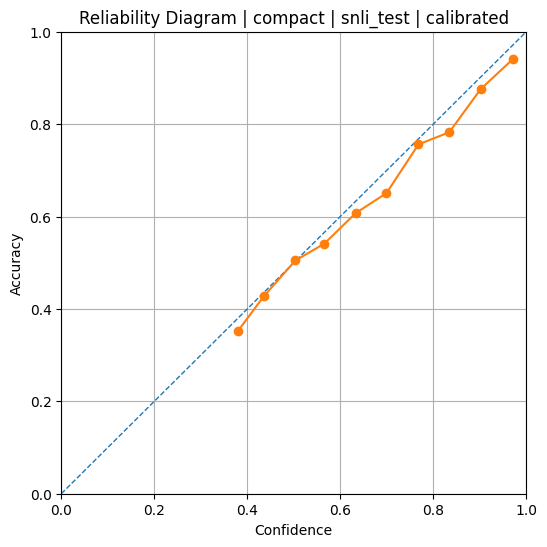

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

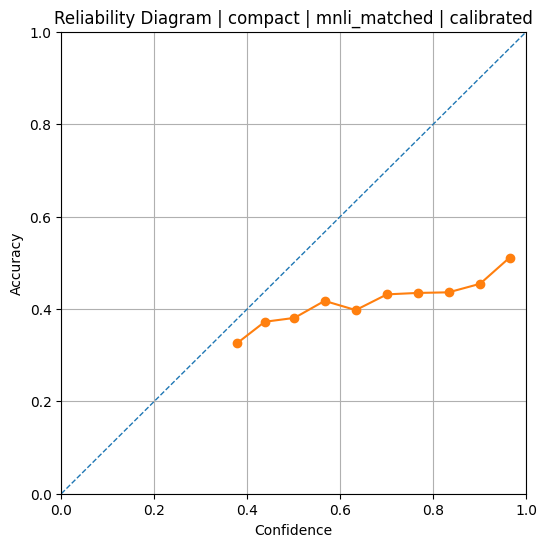

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

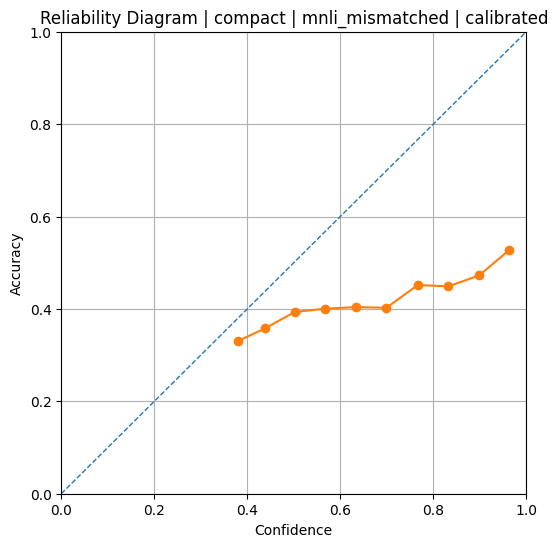

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc55bf95940>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    Exception ignored in: assert self._parent_pid == os.getpid(), 'can only test a child process'<function _MultiProcessingDataLoaderIter.__del__ at 0x7dc55bf95940>

 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive(): 
            ^^^^^^^^^^^^^^^^^^^^^^^^^

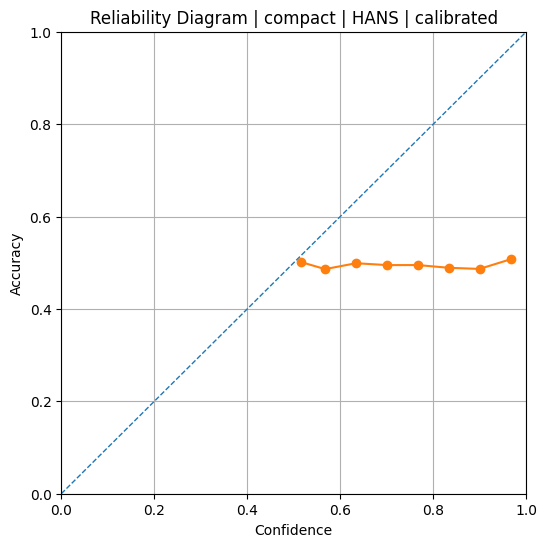

/tmp/ipykernel_24/1930030384.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.n_layers)


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

compact | seed=42 | temperature=1.1762


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

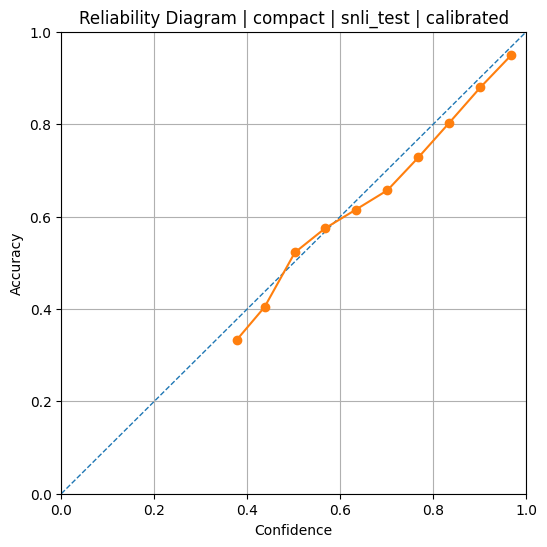

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

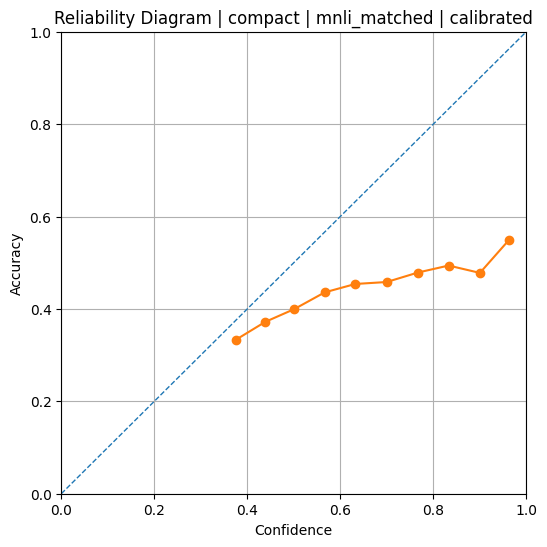

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

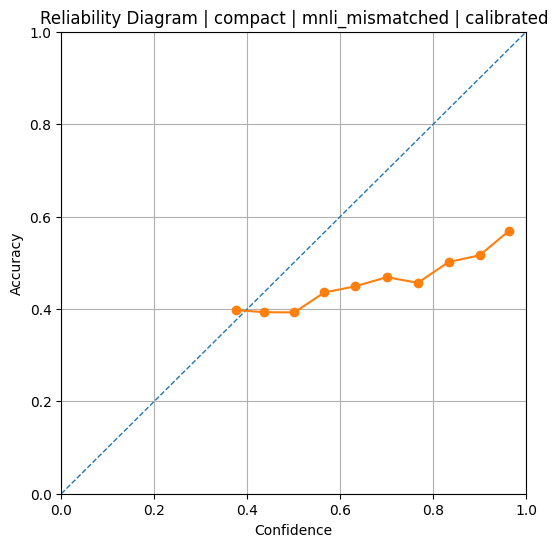

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

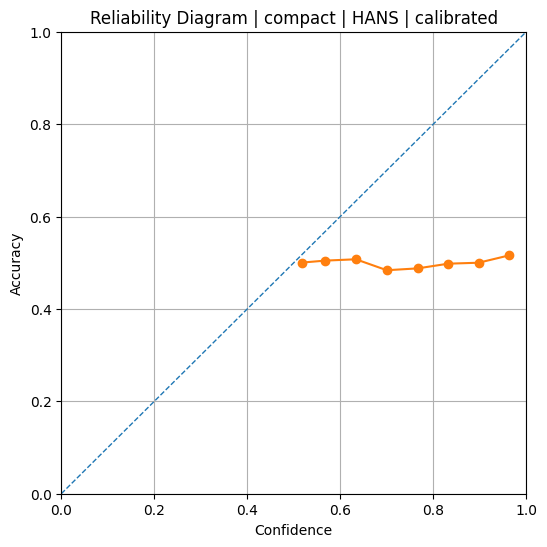

/tmp/ipykernel_24/1930030384.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.n_layers)


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

compact | seed=73 | temperature=1.1872


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

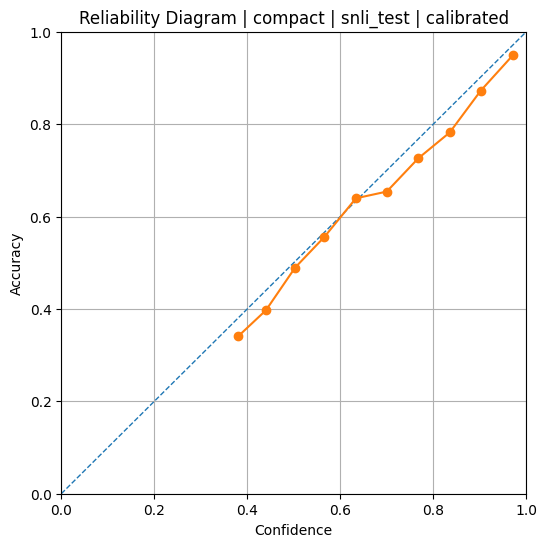

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

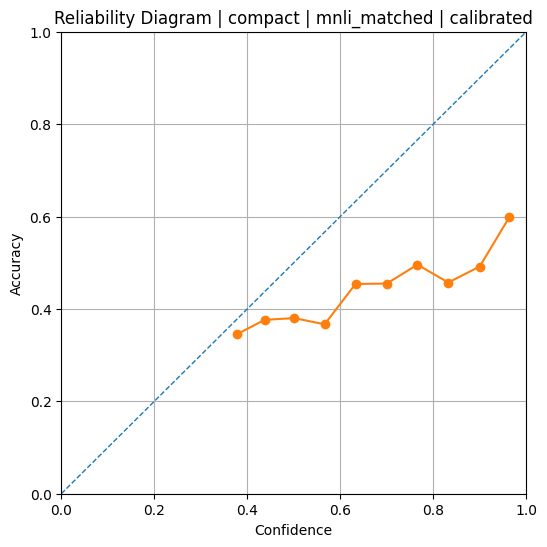

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

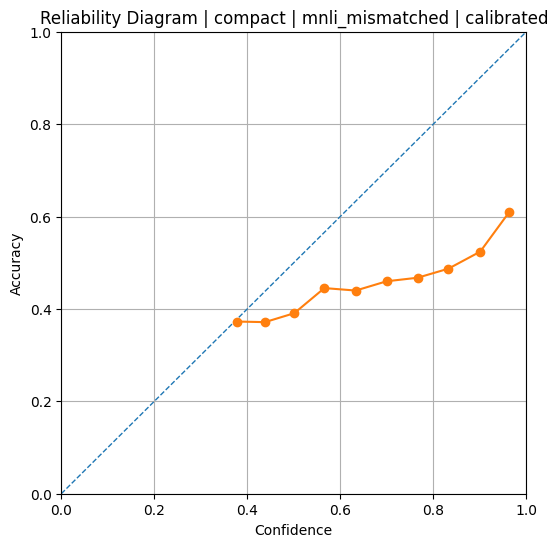

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

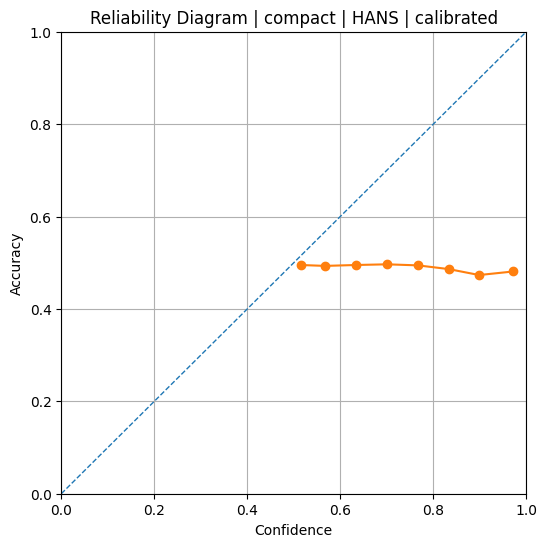

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

bert | seed=17 | temperature=1.2252


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

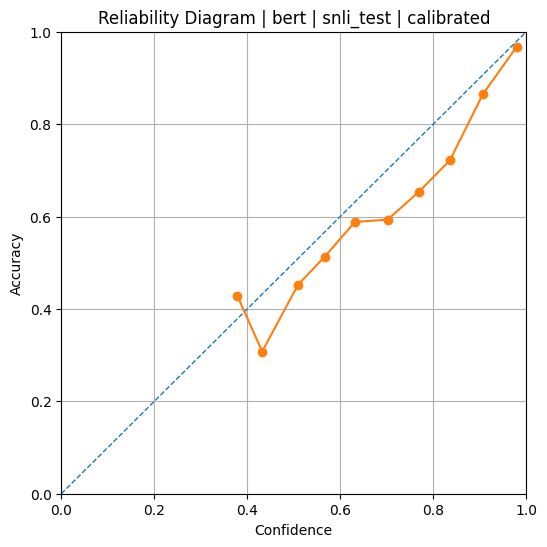

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

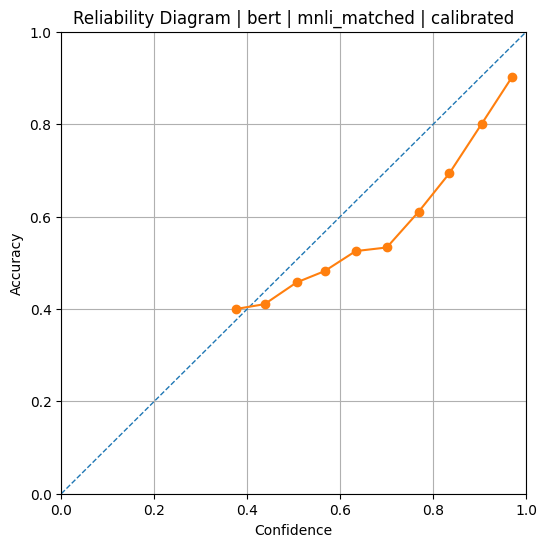

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

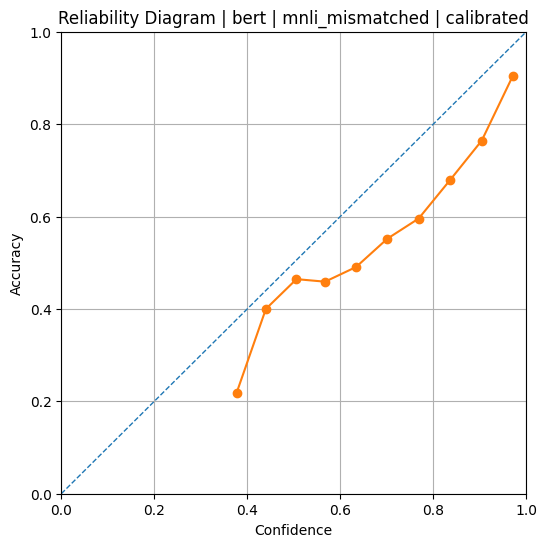

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

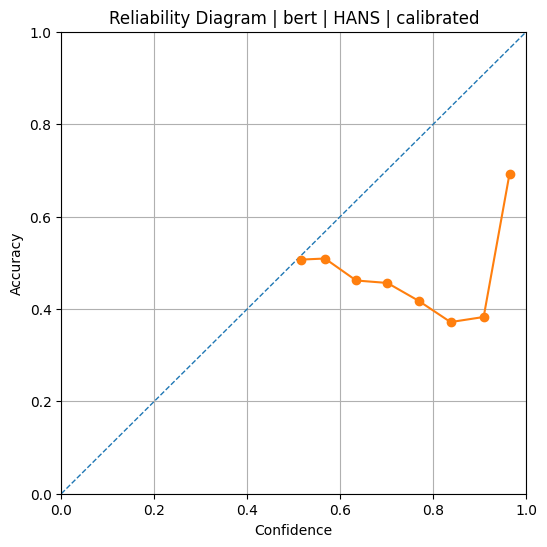

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

bert | seed=42 | temperature=1.2137


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

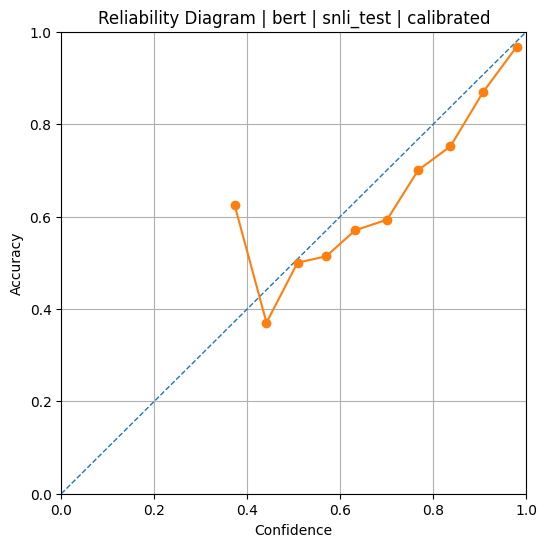

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

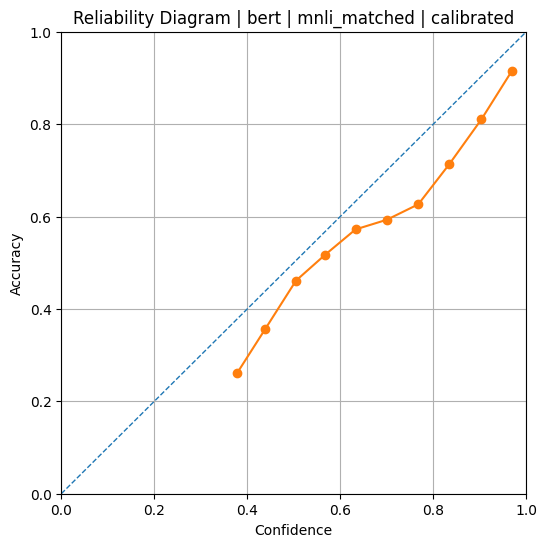

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

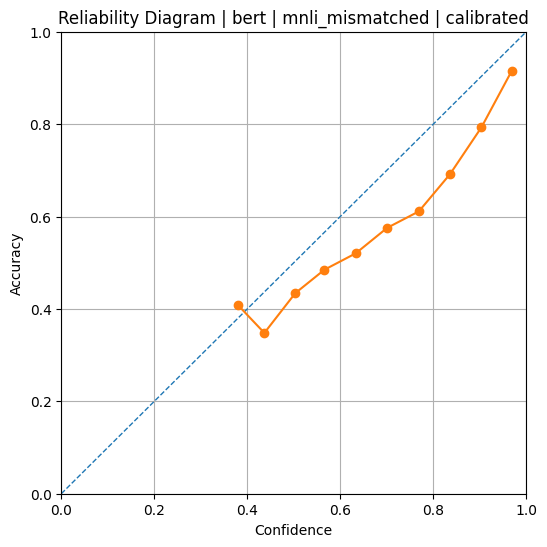

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

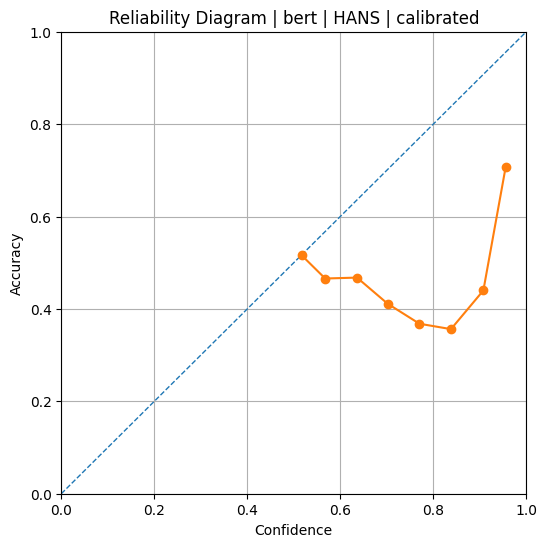

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

bert | seed=73 | temperature=1.2175


Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

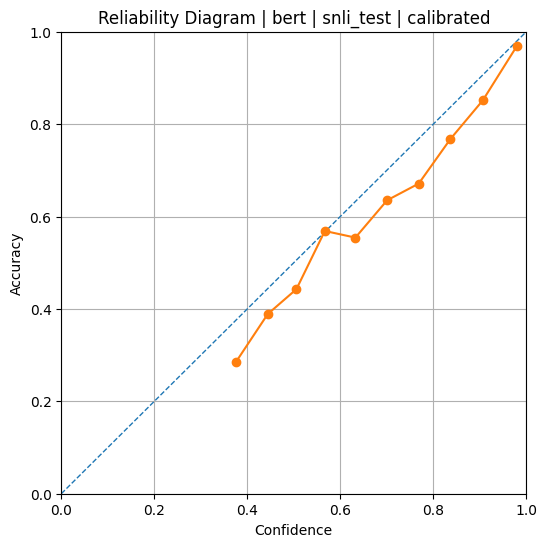

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

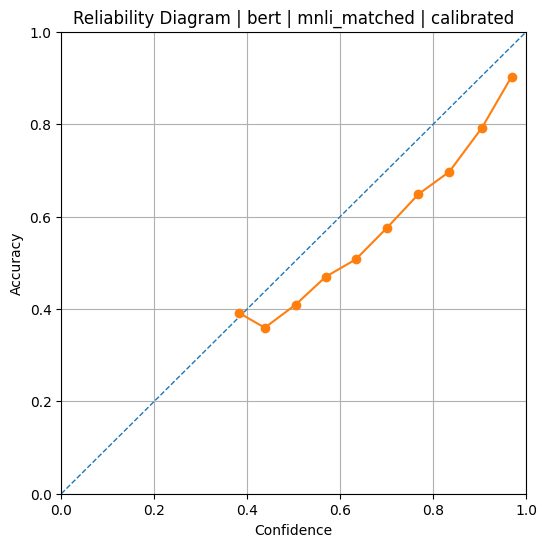

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

Predict:   0%|          | 0/154 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

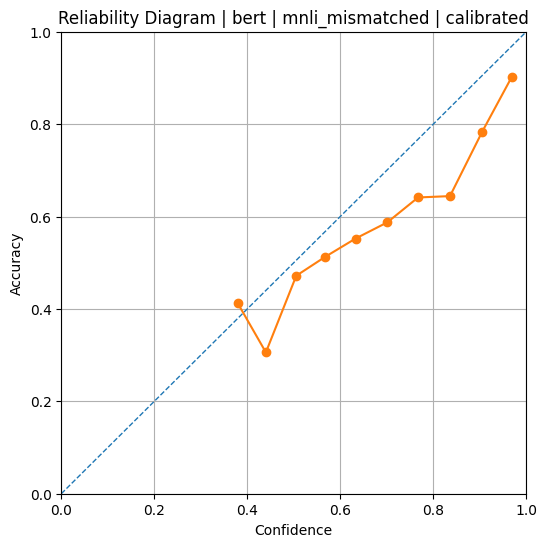

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

Eval hans:   0%|          | 0/469 [00:00<?, ?it/s]

/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
/tmp/ipykernel_24/975938911.py:153: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(n

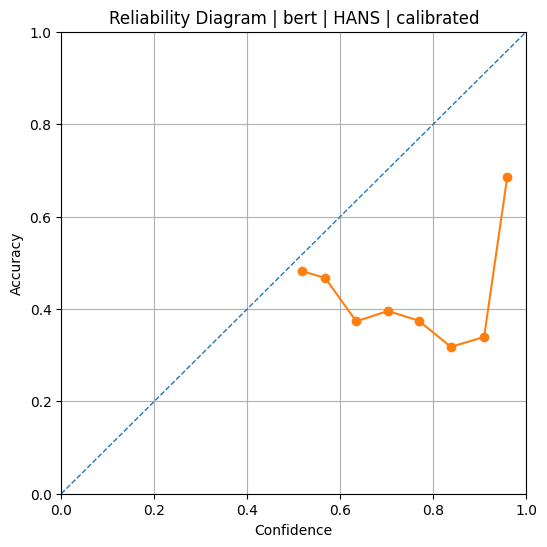

,model_name,seed,split_name,calibrated,temperature,split,accuracy,macro_f1,f1_entailment,f1_neutral,f1_contradiction,nll,brier,ece,mce,confusion_matrix,binary_f1
0,compact,17,snli_test,False,NaN,snli_test,0.742773,0.741392,0.780339,0.685878,0.757960,0.664825,0.367309,0.060561,0.097143,"[[2691, 413, 264], [548, 2154, 517], [290, 495, 2452]]",NaN
1,compact,17,snli_test,True,1.186599,snli_test,0.742773,0.741392,0.780339,0.685878,0.757960,0.642529,0.362370,0.028052,0.052028,"[[2691, 413, 264], [548, 2154, 517], [290, 495, 2452]]",NaN
2,compact,17,mnli_matched,False,NaN,mnli_matched,0.425267,0.419630,0.358170,0.454018,0.446701,1.626780,0.827493,0.308703,0.483264,"[[971, 1767, 741], [495, 1839, 789], [477, 1372, 1364]]",NaN
3,compact,17,mnli_matched,True,1.186599,mnli_matched,0.425267,0.419630,0.358170,0.454018,0.446701,1.473506,0.794949,0.274163,0.453070,"[[971, 1767, 741], [495, 1839, 789], [477, 1372, 1364]]",NaN
4,compact,17,mnli_mismatched,False,NaN,mnli_mismatched,0.427685,0.420579,0.336679,0.453063,0.471995,1.570873,0.817237,0.304607,0.463704,"[[889, 1869, 705], [534, 1875, 720], [395, 1404, 1441]]",NaN


,tokenizer_name,throughput_items_per_sec,mean_batch_latency_sec,median_batch_latency_sec,model_name,seed,trainable_params
0,google-bert/bert-base-uncased,7061.089163,0.009064,0.008784,compact,17,11039491
1,google-bert/bert-base-uncased,7157.347401,0.008942,0.008718,compact,42,11039491
2,google-bert/bert-base-uncased,7038.165236,0.009093,0.008873,compact,73,11039491
3,google-bert/bert-base-uncased,315.161696,0.203070,0.195391,bert,17,109484547
4,google-bert/bert-base-uncased,306.825197,0.208588,0.202846,bert,42,109484547
5,google-bert/bert-base-uncased,305.883312,0.209230,0.201412,bert,73,109484547


In [13]:

# Evaluation, calibration, and export
all_metrics_rows = []
all_predictions = []
all_selective_curves = []
all_quality_tables = []
all_slice_tables = []
all_benchmarks = []

def rebuild_model_for_family(model_family: str, tokenizer, cfg: ExperimentConfig) -> nn.Module:
    if model_family == "compact":
        return build_compact_model(tokenizer, cfg.compact_cfg)
    if model_family == "bert":
        return build_bert_model(cfg.bert_model_candidates[0])
    raise ValueError(model_family)

for row in training_registry:
    model_family = row["model_name"]
    seed = row["seed"]
    checkpoint_path = row["checkpoint_path"]

    model = rebuild_model_for_family(model_family, tokenizer, CFG)
    model = load_checkpoint_into_model(model, checkpoint_path)

    # Validation logits for temperature scaling
    val_loader = make_loader(
        tokenized["snli_val"],
        DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt"),
        batch_size=CFG.bert_train.eval_batch_size,
        shuffle=False,
        num_workers=2,
        seed=42,
    )
    val_pred = predict_logits(model, val_loader, DEVICE, label_key="labels")
    temperature = fit_temperature(val_pred["logits"], val_pred["labels"])
    print(f"{model_family} | seed={seed} | temperature={temperature:.4f}")

    # Benchmark on SNLI test
    snli_loader = make_loader(
        tokenized["snli_test"],
        DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt"),
        batch_size=CFG.bert_train.eval_batch_size,
        shuffle=False,
        num_workers=2,
        seed=42,
    )
    bench = benchmark_model(model, snli_loader, tokenizer_name, CFG.benchmark_warmup_steps, CFG.benchmark_steps)
    bench.update({"model_name": model_family, "seed": seed, "trainable_params": row["trainable_params"]})
    all_benchmarks.append(bench)

    for split_name in ["snli_test", "mnli_matched", "mnli_mismatched"]:
        metrics_raw, pred_df_raw = evaluate_multiclass_split(
            model=model,
            tokenizer=tokenizer,
            tokenized_ds=tokenized[split_name],
            metadata_df=metadata[split_name],
            split_name=split_name,
            model_name=model_family,
            seed=seed,
            temperature=None,
        )
        metrics_cal, pred_df_cal = evaluate_multiclass_split(
            model=model,
            tokenizer=tokenizer,
            tokenized_ds=tokenized[split_name],
            metadata_df=metadata[split_name],
            split_name=split_name,
            model_name=model_family,
            seed=seed,
            temperature=temperature,
        )

        raw_row = {"model_name": model_family, "seed": seed, "split_name": split_name, "calibrated": False, "temperature": None}
        cal_row = {"model_name": model_family, "seed": seed, "split_name": split_name, "calibrated": True, "temperature": temperature}
        for k, v in metrics_raw.items():
            if k != "ece_table":
                raw_row[k] = v
        for k, v in metrics_cal.items():
            if k != "ece_table":
                cal_row[k] = v
        all_metrics_rows.extend([raw_row, cal_row])

        pred_df_raw["calibrated"] = False
        pred_df_raw["temperature"] = np.nan
        pred_df_cal["calibrated"] = True
        pred_df_cal["temperature"] = temperature
        all_predictions.extend([pred_df_raw, pred_df_cal])

        prob_cols = ["prob_entailment", "prob_neutral", "prob_contradiction"]
        curves_raw, quality_raw = build_selective_reports(pred_df_raw, "label", prob_cols, CFG.selective_scores, CFG.fixed_coverages, split_name, model_family, seed)
        curves_cal, quality_cal = build_selective_reports(pred_df_cal, "label", prob_cols, CFG.selective_scores, CFG.fixed_coverages, split_name, model_family, seed)
        curves_raw["calibrated"] = False
        curves_cal["calibrated"] = True
        quality_raw["calibrated"] = False
        quality_cal["calibrated"] = True
        all_selective_curves.extend([curves_raw, curves_cal])
        all_quality_tables.extend([quality_raw, quality_cal])

        slice_cols = ["label", "has_negation", "lexical_overlap_bucket", "premise_len_bucket", "hypothesis_len_bucket"]
        for slice_col in slice_cols[1:]:
            sl = summarize_slice_metrics(pred_df_cal, slice_col=slice_col, y_col="label", pred_col="pred")
            sl["model_name"] = model_family
            sl["seed"] = seed
            sl["split_name"] = split_name
            sl["calibrated"] = True
            all_slice_tables.append(sl)

        build_reliability_plot(
            metrics_cal["ece_table"],
            title=f"Reliability Diagram | {model_family} | {split_name} | calibrated",
            save_path=DIRS["figures"] / f"reliability_{model_family}_seed{seed}_{split_name}_calibrated.png",
        )

    # HANS evaluation
    hans_raw, hans_df_raw = evaluate_hans_split(
        model=model,
        tokenizer=tokenizer,
        tokenized_ds=tokenized["hans"],
        metadata_df=metadata["hans"],
        split_name="hans",
        model_name=model_family,
        seed=seed,
        temperature=None,
    )
    hans_cal, hans_df_cal = evaluate_hans_split(
        model=model,
        tokenizer=tokenizer,
        tokenized_ds=tokenized["hans"],
        metadata_df=metadata["hans"],
        split_name="hans",
        model_name=model_family,
        seed=seed,
        temperature=temperature,
    )

    raw_row = {"model_name": model_family, "seed": seed, "split_name": "hans", "calibrated": False, "temperature": None}
    cal_row = {"model_name": model_family, "seed": seed, "split_name": "hans", "calibrated": True, "temperature": temperature}
    for k, v in hans_raw.items():
        if k != "ece_table":
            raw_row[k] = v
    for k, v in hans_cal.items():
        if k != "ece_table":
            cal_row[k] = v
    all_metrics_rows.extend([raw_row, cal_row])

    hans_df_raw["calibrated"] = False
    hans_df_raw["temperature"] = np.nan
    hans_df_cal["calibrated"] = True
    hans_df_cal["temperature"] = temperature
    all_predictions.extend([hans_df_raw, hans_df_cal])

    prob_cols_hans = ["prob_non_entailment", "prob_entailment"]
    curves_raw, quality_raw = build_selective_reports(hans_df_raw, "binary_label", prob_cols_hans, CFG.selective_scores, CFG.fixed_coverages, "hans", model_family, seed)
    curves_cal, quality_cal = build_selective_reports(hans_df_cal, "binary_label", prob_cols_hans, CFG.selective_scores, CFG.fixed_coverages, "hans", model_family, seed)
    curves_raw["calibrated"] = False
    curves_cal["calibrated"] = True
    quality_raw["calibrated"] = False
    quality_cal["calibrated"] = True
    all_selective_curves.extend([curves_raw, curves_cal])
    all_quality_tables.extend([quality_raw, quality_cal])

    for slice_col in ["heuristic", "subcase", "template", "has_negation", "lexical_overlap_bucket"]:
        sl = summarize_slice_metrics(hans_df_cal.rename(columns={"binary_label": "label"}), slice_col=slice_col, y_col="label", pred_col="pred")
        sl["model_name"] = model_family
        sl["seed"] = seed
        sl["split_name"] = "hans"
        sl["calibrated"] = True
        all_slice_tables.append(sl)

    build_reliability_plot(
        hans_cal["ece_table"],
        title=f"Reliability Diagram | {model_family} | HANS | calibrated",
        save_path=DIRS["figures"] / f"reliability_{model_family}_seed{seed}_hans_calibrated.png",
    )

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

metrics_df = pd.DataFrame(all_metrics_rows)
predictions_df = pd.concat(all_predictions, ignore_index=True)
selective_curves_df = pd.concat(all_selective_curves, ignore_index=True)
quality_at_cov_df = pd.concat(all_quality_tables, ignore_index=True)
slice_df = pd.concat(all_slice_tables, ignore_index=True)
benchmark_df = pd.DataFrame(all_benchmarks)

metrics_df.to_csv(DIRS["tables"] / "metrics_all.csv", index=False)
predictions_df.to_csv(DIRS["predictions"] / "all_predictions.csv", index=False)
selective_curves_df.to_csv(DIRS["tables"] / "selective_curves.csv", index=False)
quality_at_cov_df.to_csv(DIRS["tables"] / "quality_at_fixed_coverage.csv", index=False)
slice_df.to_csv(DIRS["tables"] / "slice_metrics.csv", index=False)
benchmark_df.to_csv(DIRS["tables"] / "benchmarks.csv", index=False)

display(metrics_df.head())
display(benchmark_df)

In [14]:

# Aggregate across seeds
def summarize_mean_std(df: pd.DataFrame, value_cols: List[str], group_cols: List[str]) -> pd.DataFrame:
    grouped = df.groupby(group_cols)[value_cols].agg(["mean", "std"]).reset_index()
    grouped.columns = ["__".join([c for c in col if c]).strip("_") for col in grouped.columns.to_flat_index()]
    return grouped

multiclass_metrics = metrics_df[metrics_df["split_name"] != "hans"].copy()
binary_metrics = metrics_df[metrics_df["split_name"] == "hans"].copy()

multiclass_cols = [c for c in ["accuracy", "macro_f1", "f1_entailment", "f1_neutral", "f1_contradiction", "nll", "brier", "ece", "mce"] if c in multiclass_metrics.columns]
binary_cols = [c for c in ["accuracy", "binary_f1", "nll", "brier", "ece", "mce"] if c in binary_metrics.columns]

summary_multiclass = summarize_mean_std(multiclass_metrics, multiclass_cols, ["model_name", "split_name", "calibrated"])
summary_binary = summarize_mean_std(binary_metrics, binary_cols, ["model_name", "split_name", "calibrated"])
summary_quality = summarize_mean_std(
    quality_at_cov_df,
    ["accuracy", "macro_f1"],
    ["model_name", "split_name", "calibrated", "score_name", "coverage_target"],
)
summary_bench = summarize_mean_std(
    benchmark_df,
    ["trainable_params", "throughput_items_per_sec", "mean_batch_latency_sec", "median_batch_latency_sec"],
    ["model_name"],
)

summary_multiclass.to_csv(DIRS["tables"] / "summary_multiclass_mean_std.csv", index=False)
summary_binary.to_csv(DIRS["tables"] / "summary_hans_mean_std.csv", index=False)
summary_quality.to_csv(DIRS["tables"] / "summary_quality_at_coverage_mean_std.csv", index=False)
summary_bench.to_csv(DIRS["tables"] / "summary_bench_mean_std.csv", index=False)

display(summary_multiclass)
display(summary_binary)
display(summary_bench)

,model_name,split_name,calibrated,accuracy__mean,accuracy__std,macro_f1__mean,macro_f1__std,f1_entailment__mean,f1_entailment__std,f1_neutral__mean,...,f1_contradiction__mean,f1_contradiction__std,nll__mean,nll__std,brier__mean,brier__std,ece__mean,ece__std,mce__mean,mce__std
0,bert,mnli_matched,False,0.744235,0.007164,0.741933,0.006775,0.783072,0.012591,0.686012,...,0.756715,0.008560,0.753354,0.011761,0.386205,0.004846,0.122312,0.008097,0.203011,0.018799
1,bert,mnli_matched,True,0.744235,0.007164,0.741933,0.006775,0.783072,0.012591,0.686012,...,0.756715,0.008560,0.687535,0.002090,0.373286,0.005472,0.090061,0.009115,0.148623,0.016029
2,bert,mnli_mismatched,False,0.741931,0.011757,0.738352,0.012014,0.780893,0.012446,0.671558,...,0.762606,0.009406,0.767508,0.023104,0.393945,0.007618,0.129765,0.006850,0.221994,0.008158
3,bert,mnli_mismatched,True,0.741931,0.011757,0.738352,0.012014,0.780893,0.012446,0.671558,...,0.762606,0.009406,0.697010,0.012422,0.379790,0.006943,0.098124,0.007224,0.174165,0.016976
4,bert,snli_test,False,0.905198,0.002527,0.904941,0.002523,0.913030,0.001309,0.870563,...,0.931231,0.004916,0.304528,0.007479,0.150892,0.004071,0.043663,0.001871,0.252306,0.098491
5,bert,snli_test,True,0.905198,0.002527,0.904941,0.002523,0.913030,0.001309,0.870563,...,0.931231,0.004916,0.281945,0.007810,0.147076,0.004100,0.025085,0.001608,0.158006,0.082762
6,compact,mnli_matched,False,0.439803,0.013542,0.436806,0.015836,0.410381,0.045217,0.459457,...,0.440580,0.012863,1.497144,0.113049,0.790076,0.032405,0.279738,0.025232,0.447055,0.034102
7,compact,mnli_matched,True,0.439803,0.013542,0.436806,0.015836,0.410381,0.045217,0.459457,...,0.440580,0.012863,1.370774,0.089996,0.759956,0.030329,0.245094,0.025244,0.427843,0.022968
8,compact,mnli_mismatched,False,0.446874,0.016663,0.444306,0.020634,0.403380,0.058363,0.458297,...,0.471241,0.001000,1.442946,0.111018,0.774043,0.037422,0.269938,0.030072,0.428331,0.031129
9,compact,mnli_mismatched,True,0.446874,0.016663,0.444306,0.020634,0.403380,0.058363,0.458297,...,0.471241,0.001000,1.326134,0.088239,0.744580,0.034378,0.235121,0.029849,0.402124,0.030276


,model_name,split_name,calibrated,accuracy__mean,accuracy__std,binary_f1__mean,binary_f1__std,nll__mean,nll__std,brier__mean,brier__std,ece__mean,ece__std,mce__mean,mce__std
0,bert,hans,False,0.587178,0.021344,0.705803,0.011504,1.306074,0.033756,0.722525,0.024825,0.354281,0.013430,0.562905,0.026738
1,bert,hans,True,0.588989,0.021765,0.706571,0.011780,1.082281,0.026498,0.674716,0.020765,0.323976,0.012409,0.525878,0.044134
2,compact,hans,False,0.494267,0.004694,0.533718,0.047825,1.092931,0.099911,0.702052,0.030397,0.282171,0.024210,0.472187,0.023090
3,compact,hans,True,0.493856,0.004641,0.525791,0.048581,0.995069,0.080115,0.668738,0.029787,0.253245,0.025486,0.466097,0.022430


,model_name,trainable_params__mean,trainable_params__std,throughput_items_per_sec__mean,throughput_items_per_sec__std,mean_batch_latency_sec__mean,mean_batch_latency_sec__std,median_batch_latency_sec__mean,median_batch_latency_sec__std
0,bert,109484547.0,0.0,309.290068,5.10674,0.206963,0.003386,0.199883,0.003955
1,compact,11039491.0,0.0,7085.533933,63.23968,0.009033,0.000080,0.008791,0.000078


In [15]:

# OOD deltas relative to calibrated SNLI test
base = summary_multiclass[
    (summary_multiclass["split_name"] == "snli_test") &
    (summary_multiclass["calibrated"] == True)
][["model_name", "accuracy__mean", "macro_f1__mean", "nll__mean", "brier__mean", "ece__mean"]].rename(columns={
    "accuracy__mean": "snli_accuracy",
    "macro_f1__mean": "snli_macro_f1",
    "nll__mean": "snli_nll",
    "brier__mean": "snli_brier",
    "ece__mean": "snli_ece",
})

ood = summary_multiclass[
    (summary_multiclass["split_name"].isin(["mnli_matched", "mnli_mismatched"])) &
    (summary_multiclass["calibrated"] == True)
].merge(base, on="model_name", how="left")

ood["delta_accuracy"] = ood["accuracy__mean"] - ood["snli_accuracy"]
ood["delta_macro_f1"] = ood["macro_f1__mean"] - ood["snli_macro_f1"]
ood["delta_nll"] = ood["nll__mean"] - ood["snli_nll"]
ood["delta_brier"] = ood["brier__mean"] - ood["snli_brier"]
ood["delta_ece"] = ood["ece__mean"] - ood["snli_ece"]

ood.to_csv(DIRS["tables"] / "ood_deltas.csv", index=False)
display(ood)

,model_name,split_name,calibrated,accuracy__mean,accuracy__std,macro_f1__mean,macro_f1__std,f1_entailment__mean,f1_entailment__std,f1_neutral__mean,...,snli_accuracy,snli_macro_f1,snli_nll,snli_brier,snli_ece,delta_accuracy,delta_macro_f1,delta_nll,delta_brier,delta_ece
0,bert,mnli_matched,True,0.744235,0.007164,0.741933,0.006775,0.783072,0.012591,0.686012,...,0.905198,0.904941,0.281945,0.147076,0.025085,-0.160963,-0.163008,0.405590,0.226210,0.064976
1,bert,mnli_mismatched,True,0.741931,0.011757,0.738352,0.012014,0.780893,0.012446,0.671558,...,0.905198,0.904941,0.281945,0.147076,0.025085,-0.163267,-0.166589,0.415065,0.232714,0.073039
2,compact,mnli_matched,True,0.439803,0.013542,0.436806,0.015836,0.410381,0.045217,0.459457,...,0.751255,0.749739,0.620261,0.351381,0.027419,-0.311452,-0.312933,0.750513,0.408575,0.217675
3,compact,mnli_mismatched,True,0.446874,0.016663,0.444306,0.020634,0.403380,0.058363,0.458297,...,0.751255,0.749739,0.620261,0.351381,0.027419,-0.304381,-0.305433,0.705874,0.393198,0.207702


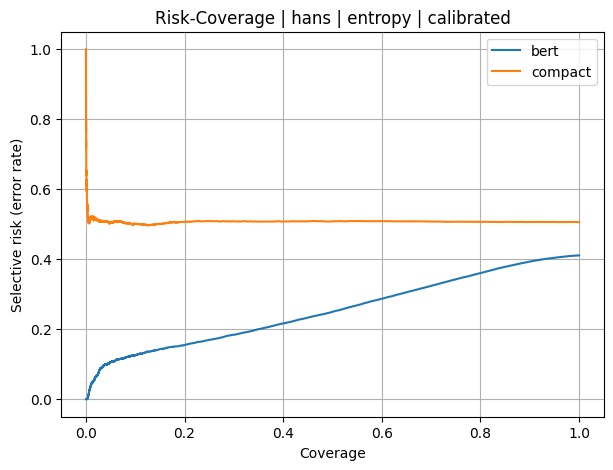

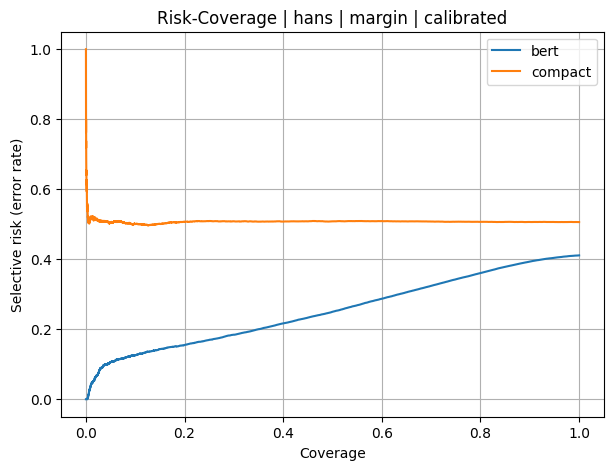

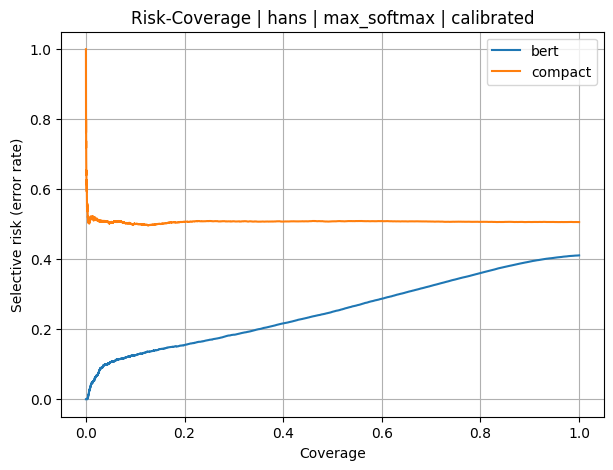

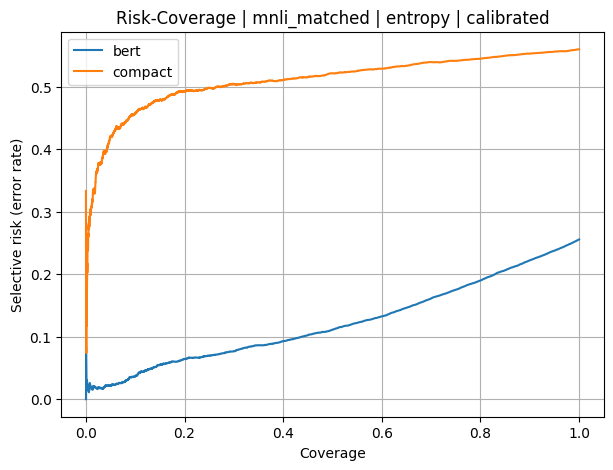

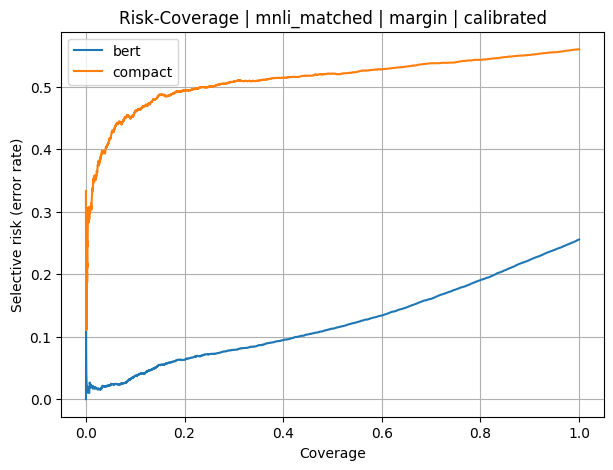

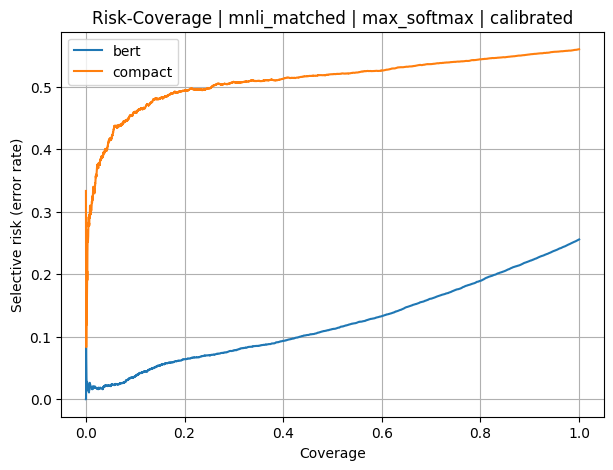

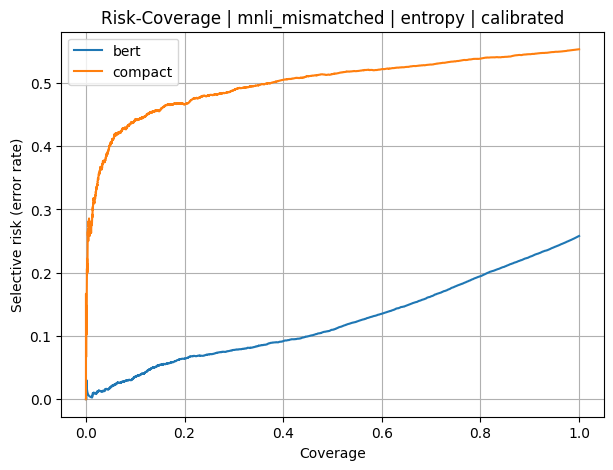

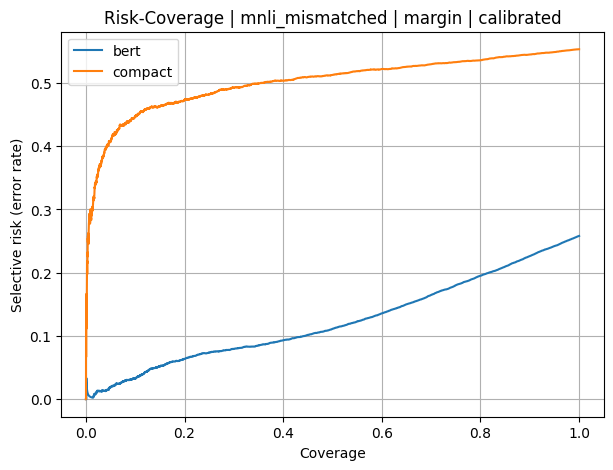

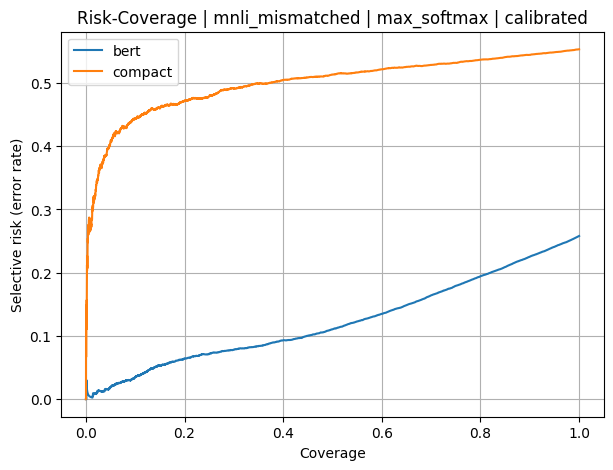

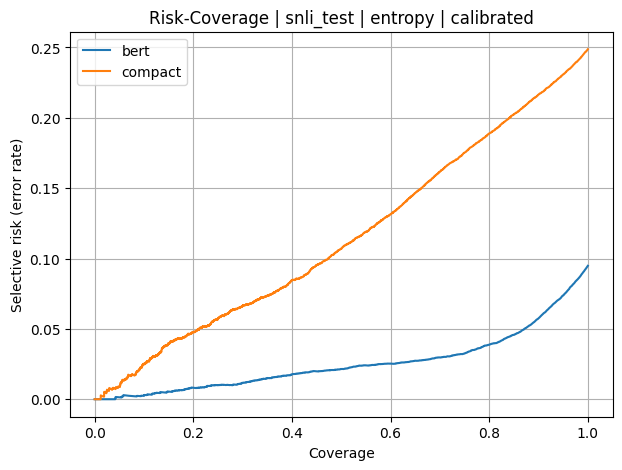

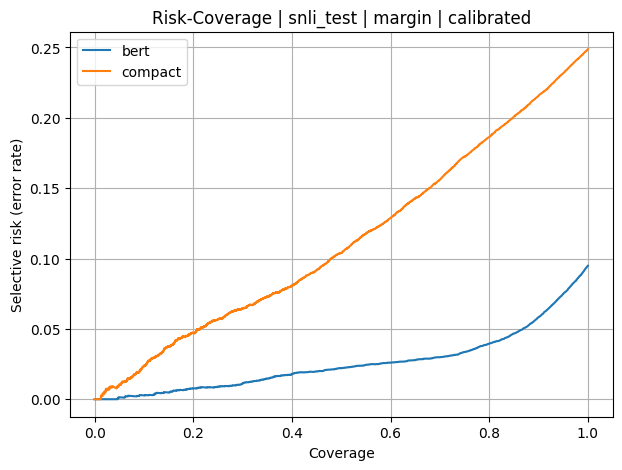

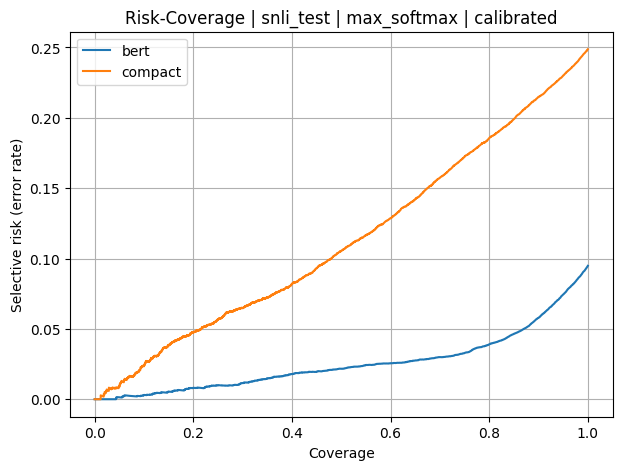

In [16]:

# Plot risk-coverage curves using calibrated predictions
cal_curves = selective_curves_df[selective_curves_df["calibrated"] == True].copy()

for split_name in sorted(cal_curves["split_name"].unique()):
    subset = cal_curves[cal_curves["split_name"] == split_name]
    for score_name in sorted(subset["score_name"].unique()):
        plt.figure(figsize=(7, 5))
        tmp = subset[subset["score_name"] == score_name]
        for model_name in sorted(tmp["model_name"].unique()):
            sub_model = tmp[tmp["model_name"] == model_name]
            mean_curve = sub_model.groupby("coverage", as_index=False)["risk"].mean().sort_values("coverage")
            plt.plot(mean_curve["coverage"], mean_curve["risk"], label=model_name)
        plt.xlabel("Coverage")
        plt.ylabel("Selective risk (error rate)")
        plt.title(f"Risk-Coverage | {split_name} | {score_name} | calibrated")
        plt.legend()
        plt.savefig(DIRS["figures"] / f"risk_coverage_{split_name}_{score_name}_calibrated.png", bbox_inches="tight")
        plt.show()

In [17]:

# Practical summary tables for the write-up
practical_table = summary_quality[
    (summary_quality["calibrated"] == True) &
    (summary_quality["score_name"] == "max_softmax") &
    (summary_quality["split_name"].isin(["snli_test", "mnli_matched", "mnli_mismatched", "hans"]))
].copy()

practical_table = practical_table.sort_values(["split_name", "coverage_target", "model_name"])
practical_table.to_csv(DIRS["tables"] / "practical_quality_table.csv", index=False)
display(practical_table)

final_report = {
    "project_name": CFG.project_name,
    "tokenizer": tokenizer_name,
    "smoke_mode": CFG.smoke_mode,
    "fixed_coverages": CFG.fixed_coverages,
    "models": sorted(training_registry_df["model_name"].unique().tolist()),
    "n_training_runs": int(len(training_registry_df)),
    "artifacts_root": str(ROOT),
}
with open(DIRS["root"] / "final_report_manifest.json", "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2)

print("Saved manifest to:", DIRS["root"] / "final_report_manifest.json")

,model_name,split_name,calibrated,score_name,coverage_target,accuracy__mean,accuracy__std,macro_f1__mean,macro_f1__std
20,bert,hans,True,max_softmax,0.70,0.676032,0.030956,0.525772,0.054942
116,compact,hans,True,max_softmax,0.70,0.492349,0.005200,0.482040,0.015227
21,bert,hans,True,max_softmax,0.80,0.639389,0.027505,0.505727,0.046422
117,compact,hans,True,max_softmax,0.80,0.493222,0.004623,0.483689,0.013834
22,bert,hans,True,max_softmax,0.90,0.606556,0.023888,0.495926,0.039435
118,compact,hans,True,max_softmax,0.90,0.493642,0.004733,0.485401,0.010953
23,bert,hans,True,max_softmax,0.95,0.595895,0.022658,0.500504,0.036653
119,compact,hans,True,max_softmax,0.95,0.493743,0.004278,0.486153,0.009940
44,bert,mnli_matched,True,max_softmax,0.70,0.839034,0.009738,0.832622,0.009235
140,compact,mnli_matched,True,max_softmax,0.70,0.463639,0.016640,0.459420,0.020729


Saved manifest to: /kaggle/working/eeml_nli_abstention/final_report_manifest.json


## What to write in the paper or abstract after the run

Use the final calibrated tables and the risk-coverage plots to formulate conclusions in this structure:

1. **Full-coverage baseline**  
   State the SNLI and OOD gap between the compact encoder and BERT at standard prediction time.

2. **Calibration effect**  
   Report whether temperature scaling reduced ECE / NLL / Brier and whether that changed the relative ranking.

3. **Selective prediction effect**  
   Report the strongest result at fixed coverages such as 95%, 90%, 80%, and 70%.  
   Example pattern:  
   *At 80% coverage on SNLI, the compact encoder recovered most of the macro-F1 gap, but under OOD shift the same coverage still left a substantial calibration and risk deficit.*

4. **OOD reliability threshold**  
   State the practical threshold clearly.  
   Example pattern:  
   *The compact encoder remained usable up to coverage X under near-shift, but under HANS or genre shift its risk rose too fast beyond coverage Y.*

5. **Failure modes**  
   Use slice analysis to identify where abstention helps and where it does not.  
   Mention negation, lexical overlap, long hypotheses, and HANS heuristics explicitly if the results support it.

Do not write vague nonsense like “the model performed well.” That phrase has ruined more reports than bad optimization ever did.